Using data file: cfsrALL.csv


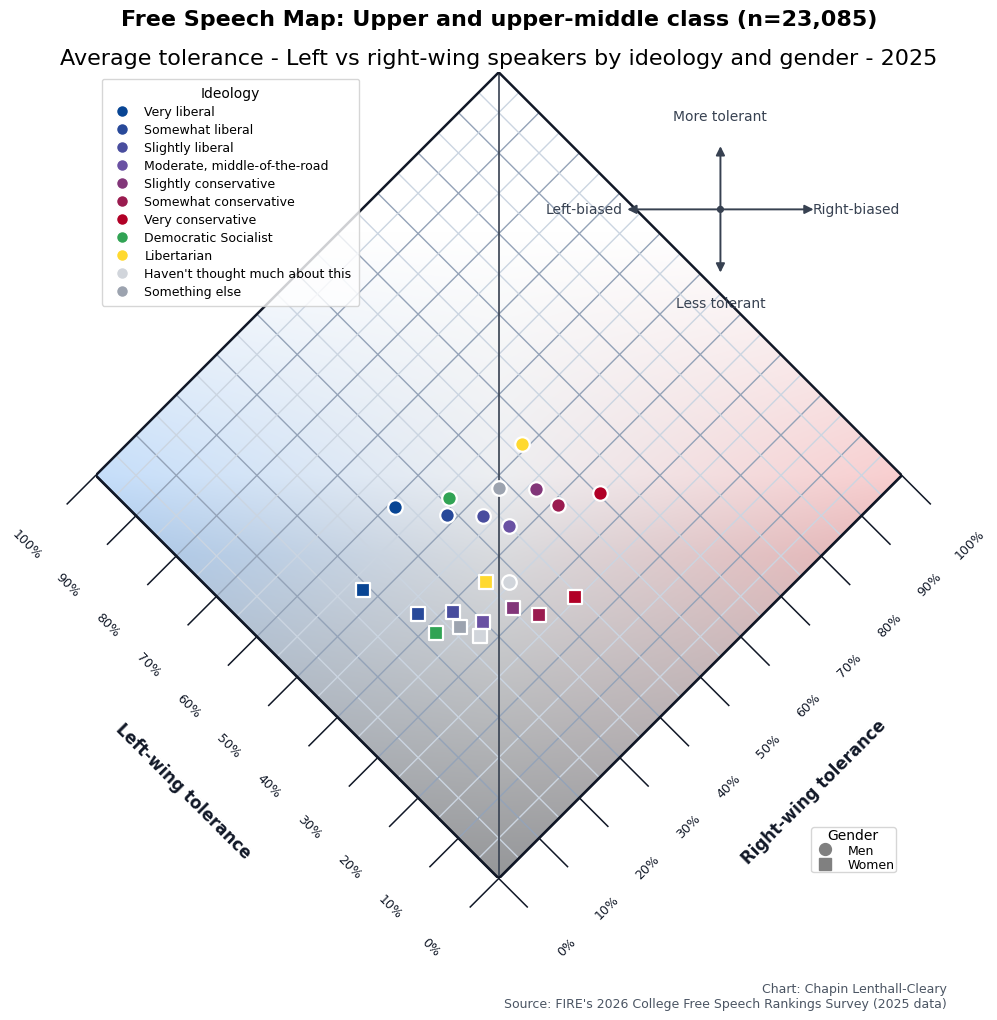

Figure saved to: /Users/chapin.lenthall-cleary/poverty_article_free_speech_map_upper_upper_middle.png


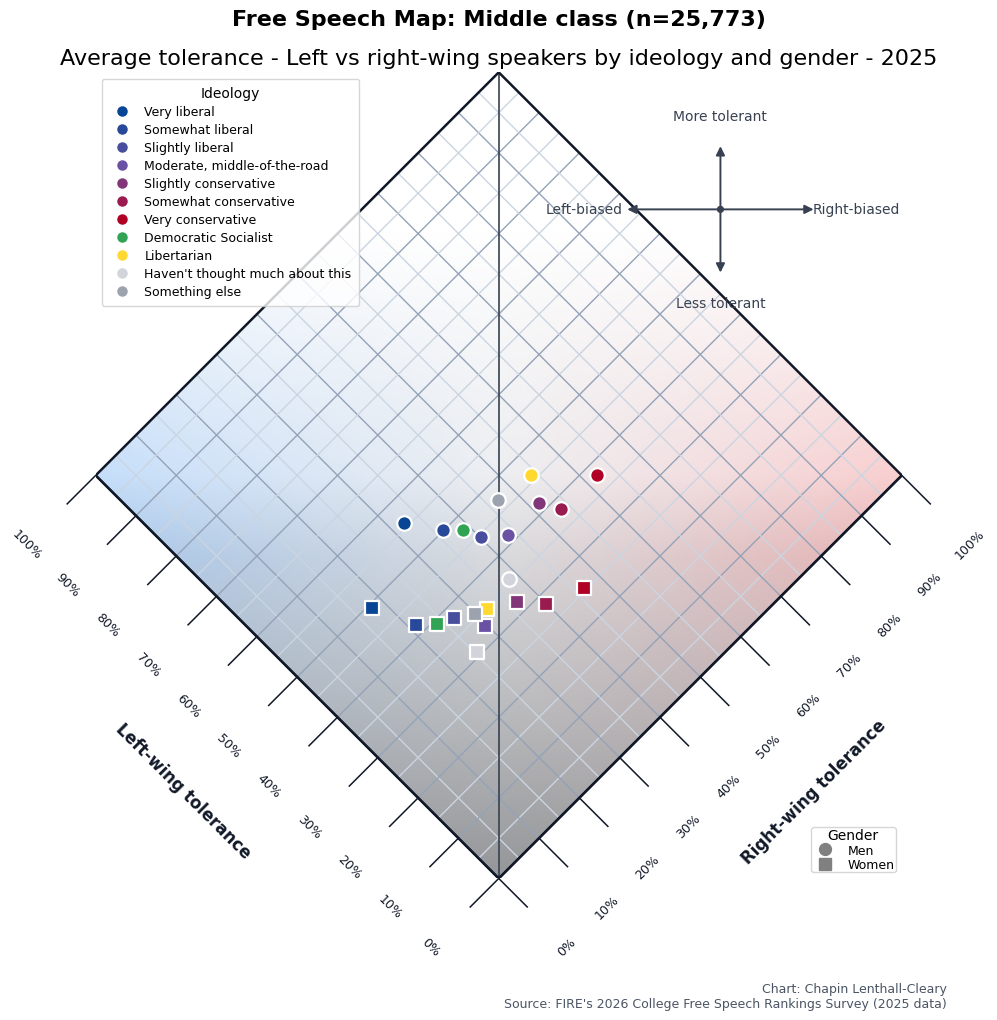

Figure saved to: /Users/chapin.lenthall-cleary/poverty_article_free_speech_map_middle.png


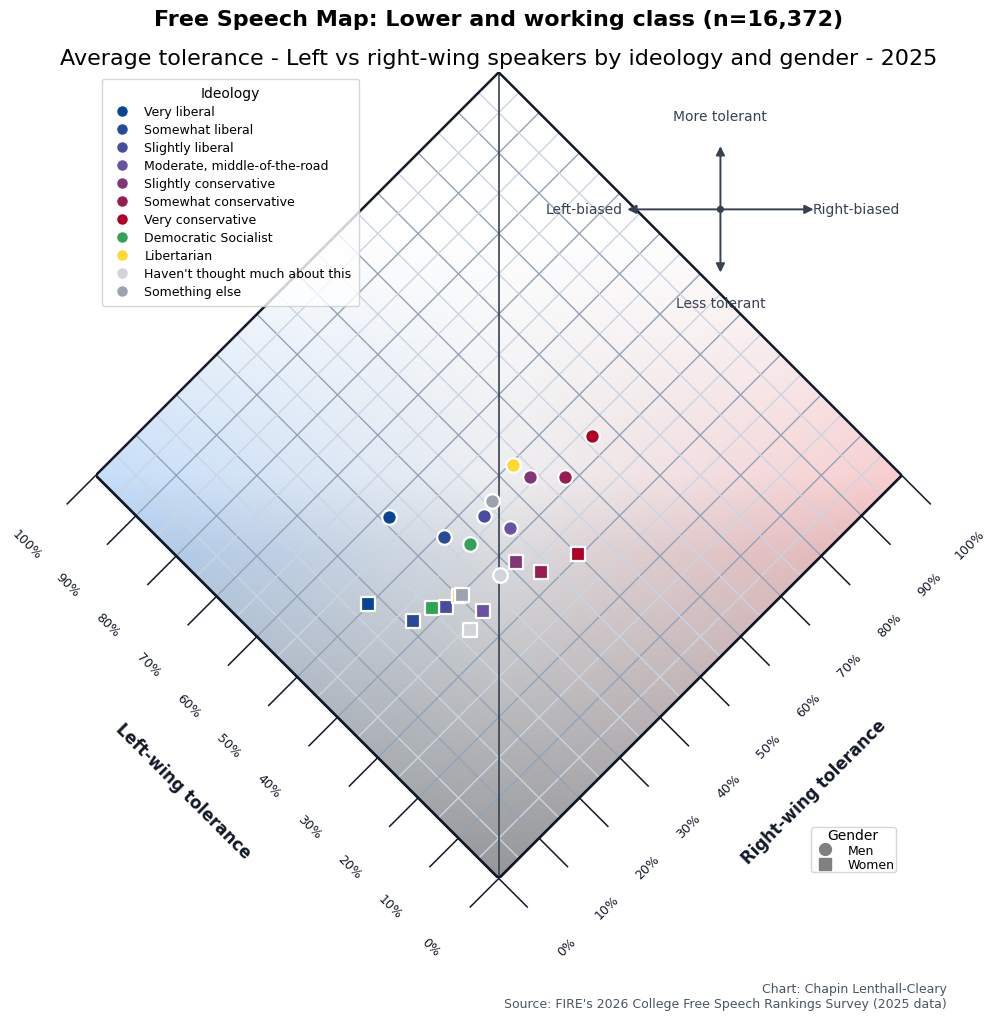

Figure saved to: /Users/chapin.lenthall-cleary/poverty_article_free_speech_map_lower_working.png


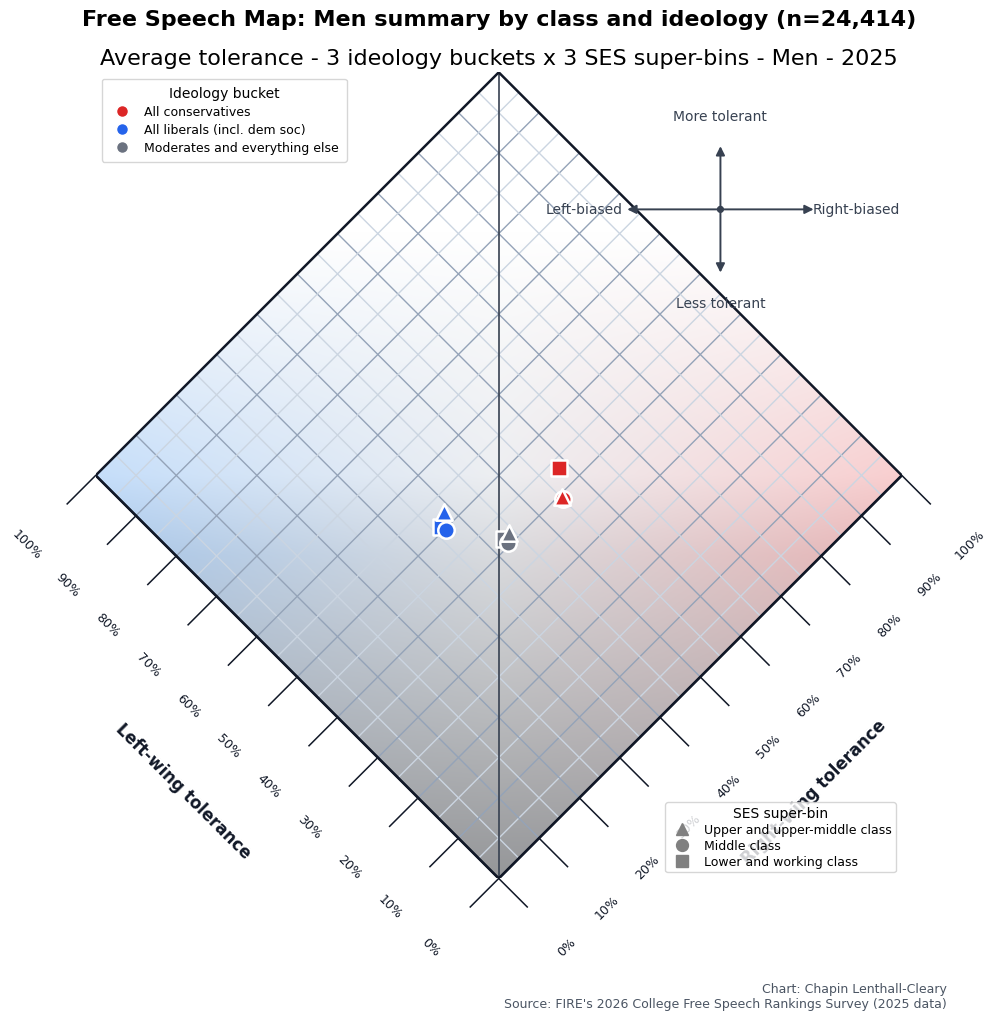

Figure saved to: /Users/chapin.lenthall-cleary/poor_article_free_speech_map_men_summary.png


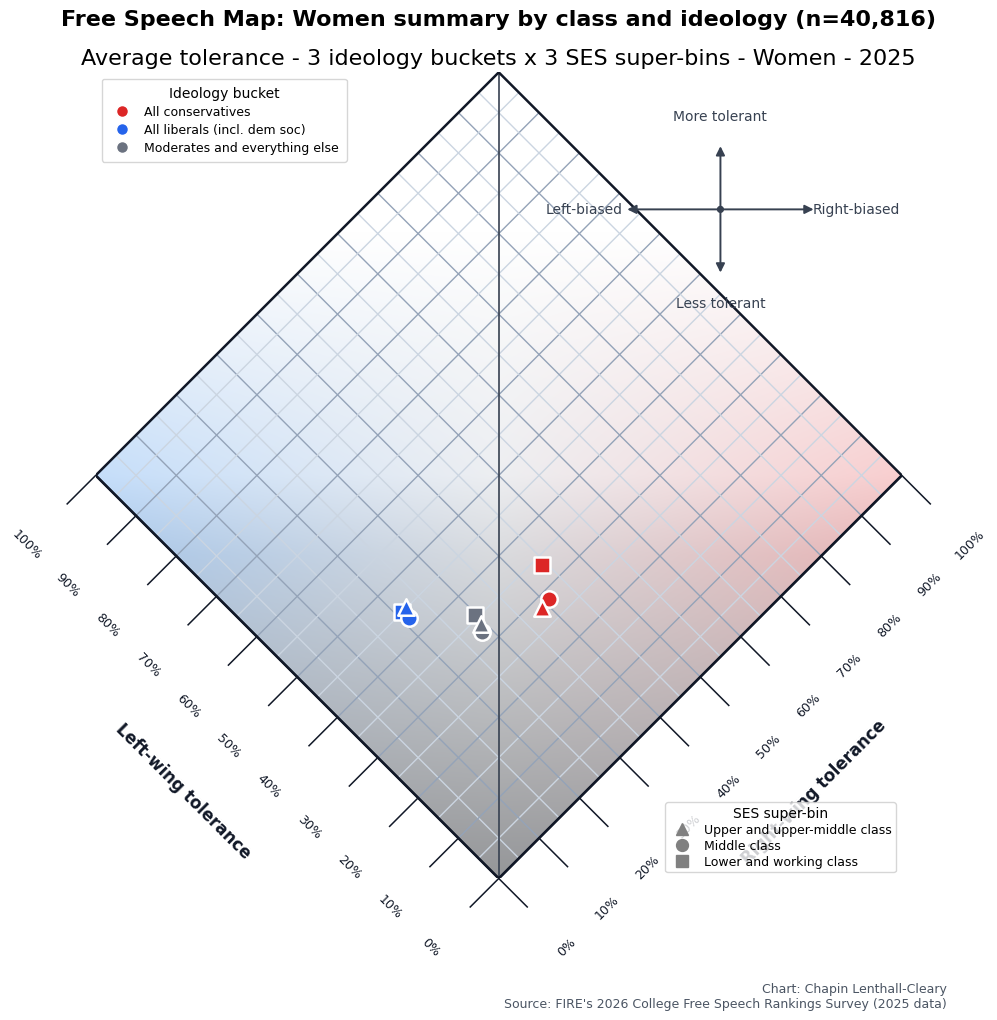

Figure saved to: /Users/chapin.lenthall-cleary/poor_article_free_speech_map_women_summary.png


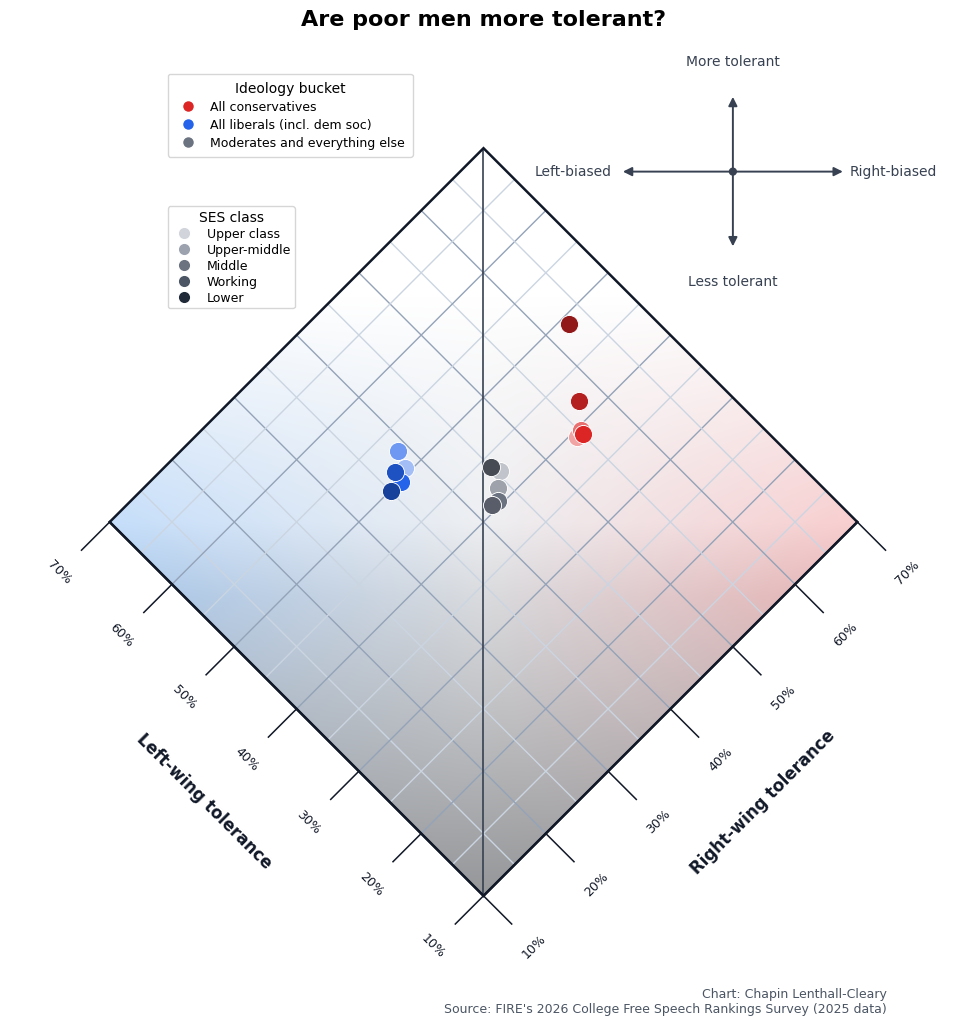

Figure saved to: /Users/chapin.lenthall-cleary/poor_article_free_speech_map_men_5ses_zoom_10_70.png


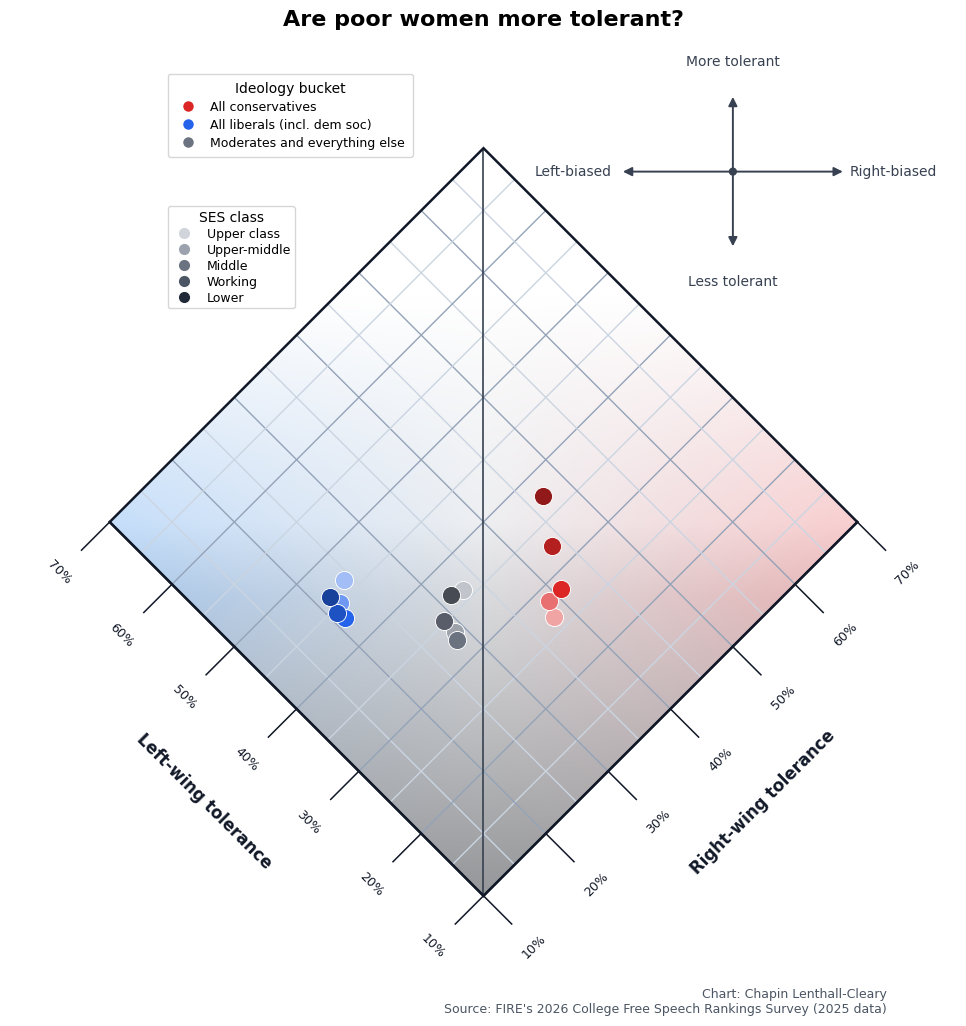

Figure saved to: /Users/chapin.lenthall-cleary/poor_article_free_speech_map_women_5ses_zoom_10_70.png


In [13]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Circle, Polygon
from pathlib import Path

# --- Config ---
YEAR = 2025
CSV_CANDIDATES = [
    Path('cfsrALL.csv'),
    Path.home() / 'cfsrALL.csv',
    Path.home() / 'allstuff' / 'cfsrALL.csv',
    Path.home() / 'megafile_longitudinal_wtf0_inputs' / 'cfsrALL.csv',
]

# --- Compass sizing/position ---
BASE_COMPASS_W = 0.30
BASE_COMPASS_H = 0.30
BASE_COMPASS_SHIFT = 0.055
H_EXPAND_PP = 0.12
COMPASS_W = BASE_COMPASS_W + H_EXPAND_PP
COMPASS_H = BASE_COMPASS_H
COMPASS_SHIFT = BASE_COMPASS_SHIFT - (COMPASS_W - BASE_COMPASS_W) / 2.0

IDEO_LABELS = {
    1: 'Very liberal',
    2: 'Somewhat liberal',
    3: 'Slightly liberal',
    4: 'Moderate, middle-of-the-road',
    5: 'Slightly conservative',
    6: 'Somewhat conservative',
    7: 'Very conservative',
    8: 'Democratic Socialist',
    9: 'Libertarian',
    10: "Haven't thought much about this",
    11: 'Something else',
}

SES_LABELS = {
    1: 'Upper class',
    2: 'Upper-middle',
    3: 'Middle',
    4: 'Working',
    5: 'Lower',
}

CLASS_GROUPS = [
    {
        'key': 'upper_upper_middle',
        'label': 'Upper and upper-middle class',
        'ses_values': [1, 2],
        'filename': 'poverty_article_free_speech_map_upper_upper_middle.png',
    },
    {
        'key': 'middle',
        'label': 'Middle class',
        'ses_values': [3],
        'filename': 'poverty_article_free_speech_map_middle.png',
    },
    {
        'key': 'lower_working',
        'label': 'Lower and working class',
        'ses_values': [4, 5],
        'filename': 'poverty_article_free_speech_map_lower_working.png',
    },
]

RIGHT_TRIAD = ['spk_abortion', 'spk_trans', 'spk_blm']
LEFT_TRIAD = ['spk_cathped', 'spk_policekkk', 'spk_kidtrans']
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD
GENDER_MARKERS = {1: 'o', 2: 's'}
GENDER_LABELS = {1: 'Men', 2: 'Women'}

cmap_lr = LinearSegmentedColormap.from_list(
    'blue_purple_red',
    ['#084594', '#6a51a3', '#b10026'],
)
steps7 = np.linspace(0, 1, 7)
IDEOLOGY_COLORS = {i: cmap_lr(steps7[i - 1]) for i in range(1, 8)}
IDEOLOGY_COLORS.update({8: '#31a354', 9: '#ffd92f', 10: '#d1d5db', 11: '#9ca3af'})

IDEOLOGY_GROUPS = [
    {
        'key': 'conservative',
        'label': 'All conservatives',
        'ideo_values': [5, 6, 7],
        'color': '#dc2626',
    },
    {
        'key': 'liberal',
        'label': 'All liberals (incl. dem soc)',
        'ideo_values': [1, 2, 3, 8],
        'color': '#2563eb',
    },
    {
        'key': 'moderate_other',
        'label': 'Moderates and everything else',
        'ideo_values': [4, 9, 10, 11],
        'color': '#6b7280',
    },
]
IDEOLOGY_GROUP_LABELS = {group['key']: group['label'] for group in IDEOLOGY_GROUPS}
IDEOLOGY_GROUP_COLORS = {group['key']: group['color'] for group in IDEOLOGY_GROUPS}
CLASS_GROUP_LABELS = {group['key']: group['label'] for group in CLASS_GROUPS}
CLASS_GROUP_MARKERS = {
    'upper_upper_middle': '^',
    'middle': 'o',
    'lower_working': 's',
}
SES_CLASS_DOT_COLORS = {
    1: '#d1d5db',
    2: '#9ca3af',
    3: '#6b7280',
    4: '#4b5563',
    5: '#1f2937',
}
SES_CLASS_SHADE_BLEND = {
    1: ('#ffffff', 0.58),
    2: ('#ffffff', 0.34),
    3: ('#000000', 0.00),
    4: ('#000000', 0.18),
    5: ('#000000', 0.34),
}


def find_csv_path():
    for candidate in CSV_CANDIDATES:
        if candidate.exists():
            return candidate
    checked = '\n'.join(f'  - {p}' for p in CSV_CANDIDATES)
    raise FileNotFoundError(f'Could not find cfsrALL.csv. Checked:\n{checked}')


def numeric_series(df, col):
    if col in df.columns:
        return pd.to_numeric(df[col], errors='coerce')
    return pd.Series(np.nan, index=df.index)


def scale_triad_to_pct(sum_vals, k=3):
    return (sum_vals - k) / (3 * k) * 100.0


def build_ideo_like_code(df):
    fire = numeric_series(df, 'fire_ideo')
    cp = numeric_series(df, 'cp_ideo')
    raw = numeric_series(df, 'ideo')
    valid_fire = (fire >= 1) & (fire <= 11)
    valid_cp = (cp >= 1) & (cp <= 11)
    valid_raw = (raw >= 1) & (raw <= 11)
    ideo = np.where(valid_fire, fire, np.where(valid_cp, cp, np.where(valid_raw, raw, np.nan)))
    return pd.Series(ideo, index=df.index).astype('Int64')


# ---------- Diamond coordinate mapping ----------
P0 = np.array([50.0, 0.0])
VL = np.array([-50.0, 50.0])
VR = np.array([50.0, 50.0])


def to_diamond(left, right):
    s_left = np.asarray(left) / 100.0
    s_right = np.asarray(right) / 100.0
    xy = P0 + s_left * VL + s_right * VR
    return float(xy[0]), float(xy[1])


def ses_shaded_color(base_color, ses):
    blend_color, amount = SES_CLASS_SHADE_BLEND.get(int(ses), ('#000000', 0.0))
    base = np.array(to_rgb(base_color))
    target = np.array(to_rgb(blend_color))
    return tuple((1 - amount) * base + amount * target)


# ---------- Map scaffolding from the SES free speech map ----------
def add_2d_gradient_bg(ax, diamond_outline, nx=800, ny=800, extent=None):
    x = np.linspace(0.0, 1.0, nx)
    y = np.linspace(0.0, 1.0, ny)
    X, Y = np.meshgrid(x, y)

    c_left = np.array(to_rgb('#93c5fd'))
    c_mid = np.array(to_rgb('#e5e7eb'))
    c_right = np.array(to_rgb('#fca5a5'))

    H = np.zeros((ny, nx, 3), dtype=float)
    u_left = np.clip(2 * X, 0, 1)
    u_right = np.clip(2 * (X - 0.5), 0, 1)
    for ch in range(3):
        H[..., ch] = np.where(
            X <= 0.5,
            (1 - u_left) * c_left[ch] + u_left * c_mid[ch],
            (1 - u_right) * c_mid[ch] + u_right * c_right[ch],
        )

    white = np.array(to_rgb('#ffffff'))
    gray = np.array(to_rgb('#e5e7eb'))
    t = np.clip(Y / 0.80, 0, 1)
    V = (1 - t)[..., None] * gray + t[..., None] * white

    bell = 1.0 - np.abs(2 * t - 1.0)
    alpha = 0.65 * bell
    IMG = (1 - alpha)[..., None] * V + alpha[..., None] * H

    shade_strength = np.clip((0.5 - Y) / 0.5, 0.0, 1.0)
    IMG *= 1.0 - 0.35 * shade_strength[..., None]
    IMG = np.clip(IMG, 0.0, 1.0)
    IMG[Y >= 0.85] = white

    if extent is None:
        extent = [0, 100, 0, 100]

    im = ax.imshow(
        IMG,
        origin='lower',
        extent=extent,
        interpolation='bilinear',
        zorder=-10,
    )
    im.set_clip_path(diamond_outline)


def add_compass(ax, width, height, shift_left, pad=0.02):
    cx = 1 - pad - width / 2 - shift_left
    cy = 1 - pad - height / 2

    hx = width / 2.0
    hy = height / 2.0
    margin = min(width, height) * 0.06

    def r_max(theta):
        ct = max(abs(np.cos(theta)), 1e-9)
        st = max(abs(np.sin(theta)), 1e-9)
        return min((hx - margin) / ct, (hy - margin) / st)

    directions = [
        (90, 'More tolerant'),
        (180, 'Left-biased'),
        (0, 'Right-biased'),
        (270, 'Less tolerant'),
    ]
    color = '#374151'
    for angle_deg, label in directions:
        theta = np.deg2rad(angle_deg)
        radius = r_max(theta)
        arrow_radius = radius * 0.62
        label_radius = radius * 0.88
        x_tip = cx + arrow_radius * np.cos(theta)
        y_tip = cy + arrow_radius * np.sin(theta)
        ax.add_patch(FancyArrowPatch(
            (cx, cy),
            (x_tip, y_tip),
            transform=ax.transAxes,
            arrowstyle='-|>',
            mutation_scale=13,
            linewidth=1.4,
            color=color,
            zorder=9,
        ))
        ax.text(
            cx + label_radius * np.cos(theta),
            cy + label_radius * np.sin(theta),
            label,
            transform=ax.transAxes,
            ha='center',
            va='center',
            fontsize=10,
            color=color,
            zorder=10,
        )

    ax.add_patch(Circle(
        (cx, cy),
        radius=min(width, height) * 0.012,
        transform=ax.transAxes,
        color=color,
        zorder=10,
    ))


def draw_edge_axis(
    ax,
    p0,
    p1,
    label,
    tick_vals=range(0, 101, 10),
    tick_len=4.0,
    label_pad=18.0,
    tick_label_pad=6.0,
    label_fontsize=12,
    tick_fontsize=9,
    color='#111827',
    increasing_from='start',
):
    p0 = np.asarray(p0, float)
    p1 = np.asarray(p1, float)
    v = p1 - p0
    length = float(np.hypot(v[0], v[1]))
    if length == 0:
        return
    u = v / length

    n_cw = np.array([u[1], -u[0]])
    n_ccw = np.array([-u[1], u[0]])
    n = n_cw if n_cw[1] < n_ccw[1] else n_ccw

    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, linewidth=1.6, zorder=4)
    edge_angle_deg = np.degrees(np.arctan2(v[1], v[0]))

    for tick in tick_vals:
        s = tick / 100.0
        pt = (p1 - u * (s * length)) if increasing_from == 'end' else (p0 + u * (s * length))
        p_tick_end = pt + n * tick_len
        ax.plot(
            [pt[0], p_tick_end[0]],
            [pt[1], p_tick_end[1]],
            color=color,
            linewidth=1.1,
            zorder=4,
            clip_on=False,
        )
        p_text = pt + n * (tick_len + tick_label_pad)
        ax.text(
            p_text[0],
            p_text[1],
            f'{tick}%',
            ha='center',
            va='center',
            fontsize=tick_fontsize,
            color=color,
            rotation=edge_angle_deg,
            rotation_mode='anchor',
            zorder=5,
            clip_on=False,
        )

    mid = (p0 + p1) / 2.0
    p_label = mid + n * label_pad
    ax.text(
        p_label[0],
        p_label[1],
        label,
        ha='center',
        va='center',
        fontsize=label_fontsize,
        color=color,
        fontweight='bold',
        rotation=edge_angle_deg,
        rotation_mode='anchor',
        zorder=5,
        clip_on=False,
    )


def draw_diamond(ax):
    diamond_xy = np.array([[50, 100], [100, 50], [50, 0], [0, 50]], dtype=float)
    diamond_outline = Polygon(
        diamond_xy,
        closed=True,
        facecolor='none',
        edgecolor='#111827',
        linewidth=1.8,
        zorder=3,
        joinstyle='miter',
    )
    ax.add_patch(diamond_outline)
    add_2d_gradient_bg(ax, diamond_outline)

    grid_artists = []
    for value in range(0, 101, 5):
        color = '#94a3b8' if (value // 5) % 2 == 0 else '#cbd5e1'
        x1, y1 = to_diamond(value, 0)
        x2, y2 = to_diamond(value, 100)
        line1, = ax.plot([x1, x2], [y1, y2], color=color, linewidth=1.0, zorder=0)
        x3, y3 = to_diamond(0, value)
        x4, y4 = to_diamond(100, value)
        line2, = ax.plot([x3, x4], [y3, y4], color=color, linewidth=1.0, zorder=0)
        grid_artists.extend([line1, line2])

    x0, y0 = to_diamond(0, 0)
    x_top, y_top = to_diamond(100, 100)
    parity_line, = ax.plot([x0, x_top], [y0, y_top], color='#374151', linewidth=1.2, zorder=1.5)
    for art in grid_artists + [parity_line]:
        art.set_clip_path(diamond_outline)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal', adjustable='box')

    draw_edge_axis(
        ax,
        (0, 50),
        (50, 0),
        label='Left-wing tolerance',
        increasing_from='end',
        label_pad=20,
        tick_label_pad=7,
        tick_len=5.0,
    )
    draw_edge_axis(
        ax,
        (50, 0),
        (100, 50),
        label='Right-wing tolerance',
        label_pad=20,
        tick_label_pad=7,
        tick_len=5.0,
    )
    add_compass(ax, width=COMPASS_W, height=COMPASS_H, shift_left=COMPASS_SHIFT)


def draw_zoom_edge_axis(ax, axis, lo=10, hi=70, tick_len=3.2, tick_label_pad=2.5, label_pad=10.5):
    if axis == 'left':
        p0 = np.asarray(to_diamond(lo, lo), float)
        p1 = np.asarray(to_diamond(hi, lo), float)
        tick_point = lambda value: np.asarray(to_diamond(value, lo), float)
        label = 'Left-wing tolerance'
    else:
        p0 = np.asarray(to_diamond(lo, lo), float)
        p1 = np.asarray(to_diamond(lo, hi), float)
        tick_point = lambda value: np.asarray(to_diamond(lo, value), float)
        label = 'Right-wing tolerance'

    v = p1 - p0
    length = float(np.hypot(v[0], v[1]))
    if length == 0:
        return
    u = v / length
    n_cw = np.array([u[1], -u[0]])
    n_ccw = np.array([-u[1], u[0]])
    n = n_cw if n_cw[1] < n_ccw[1] else n_ccw
    edge_angle_deg = np.degrees(np.arctan2(v[1], v[0]))
    text_angle_deg = edge_angle_deg - 180 if axis == 'left' else edge_angle_deg

    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color='#111827', linewidth=1.6, zorder=4)
    for tick in range(lo, hi + 1, 10):
        pt = tick_point(tick)
        p_tick_end = pt + n * tick_len
        ax.plot(
            [pt[0], p_tick_end[0]],
            [pt[1], p_tick_end[1]],
            color='#111827',
            linewidth=1.1,
            zorder=4,
            clip_on=False,
        )
        p_text = pt + n * (tick_len + tick_label_pad)
        ax.text(
            p_text[0],
            p_text[1],
            f'{tick}%',
            ha='center',
            va='center',
            fontsize=9,
            color='#111827',
            rotation=text_angle_deg,
            rotation_mode='anchor',
            zorder=5,
            clip_on=False,
        )

    mid = (p0 + p1) / 2.0
    p_label = mid + n * label_pad
    ax.text(
        p_label[0],
        p_label[1],
        label,
        ha='center',
        va='center',
        fontsize=12,
        color='#111827',
        fontweight='bold',
        rotation=text_angle_deg,
        rotation_mode='anchor',
        zorder=5,
        clip_on=False,
    )


def draw_zoomed_diamond(ax, lo=10, hi=70):
    zoom_xy = np.array(
        [
            to_diamond(lo, lo),
            to_diamond(hi, lo),
            to_diamond(hi, hi),
            to_diamond(lo, hi),
        ],
        dtype=float,
    )
    zoom_outline = Polygon(
        zoom_xy,
        closed=True,
        facecolor='none',
        edgecolor='#111827',
        linewidth=1.8,
        zorder=3,
        joinstyle='miter',
    )
    ax.add_patch(zoom_outline)
    zoom_extent = [
        float(zoom_xy[:, 0].min()),
        float(zoom_xy[:, 0].max()),
        float(zoom_xy[:, 1].min()),
        float(zoom_xy[:, 1].max()),
    ]
    add_2d_gradient_bg(ax, zoom_outline, extent=zoom_extent)

    grid_artists = []
    for value in range(lo, hi + 1, 5):
        color = '#94a3b8' if (value // 5) % 2 == 0 else '#cbd5e1'
        x1, y1 = to_diamond(value, lo)
        x2, y2 = to_diamond(value, hi)
        line1, = ax.plot([x1, x2], [y1, y2], color=color, linewidth=1.0, zorder=0)
        x3, y3 = to_diamond(lo, value)
        x4, y4 = to_diamond(hi, value)
        line2, = ax.plot([x3, x4], [y3, y4], color=color, linewidth=1.0, zorder=0)
        grid_artists.extend([line1, line2])

    x0, y0 = to_diamond(lo, lo)
    x_top, y_top = to_diamond(hi, hi)
    parity_line, = ax.plot([x0, x_top], [y0, y_top], color='#374151', linewidth=1.2, zorder=1.5)
    for art in grid_artists + [parity_line]:
        art.set_clip_path(zoom_outline)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(float(zoom_xy[:, 0].min()) - 8, float(zoom_xy[:, 0].max()) + 8)
    ax.set_ylim(float(zoom_xy[:, 1].min()) - 8, float(zoom_xy[:, 1].max()) + 8)
    ax.set_aspect('equal', adjustable='box')

    draw_zoom_edge_axis(ax, 'left', lo=lo, hi=hi)
    draw_zoom_edge_axis(ax, 'right', lo=lo, hi=hi)
    add_compass(ax, width=COMPASS_W, height=COMPASS_H, shift_left=COMPASS_SHIFT + 0.0516666667, pad=-0.02)
    return zoom_outline


def prep_stats(df, group_cols):
    d = df.copy()
    d['right_sum'] = d[RIGHT_TRIAD].sum(axis=1).astype(int)
    d['left_sum'] = d[LEFT_TRIAD].sum(axis=1).astype(int)
    d['right_pct'] = scale_triad_to_pct(d['right_sum'], k=len(RIGHT_TRIAD))
    d['left_pct'] = scale_triad_to_pct(d['left_sum'], k=len(LEFT_TRIAD))
    return (
        d.groupby(group_cols, dropna=True)
        .agg(
            left_avg=('left_pct', 'mean'),
            right_avg=('right_pct', 'mean'),
            n=('left_pct', 'size'),
        )
        .reset_index()
    )


def load_filtered_data():
    csv_path = find_csv_path()
    print(f'Using data file: {csv_path}')
    df = pd.read_csv(csv_path, low_memory=False)

    required = ['datayear', 'gender_bin', 'ses', *SPK_ALL]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f'Missing required columns: {missing}')

    for col in required:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['ideo'] = build_ideo_like_code(df)

    df = df[
        (df['datayear'] == YEAR)
        & (df['gender_bin'].isin([1, 2]))
        & (df['ideo'].isin(range(1, 12)))
        & (df['ses'].isin([1, 2, 3, 4, 5]))
    ].copy()
    if df.empty:
        raise SystemExit(f'No rows for datayear == {YEAR}, genders in [1,2], ideo in 1..11, and ses in 1..5.')

    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()
    if df.empty:
        raise SystemExit('No rows remain after requiring all six spk_* variables in [1,4].')

    df['class_group'] = pd.NA
    df.loc[df['ses'].isin([1, 2]), 'class_group'] = 'upper_upper_middle'
    df.loc[df['ses'].eq(3), 'class_group'] = 'middle'
    df.loc[df['ses'].isin([4, 5]), 'class_group'] = 'lower_working'

    df['ideology_group'] = pd.NA
    df.loc[df['ideo'].isin([5, 6, 7]), 'ideology_group'] = 'conservative'
    df.loc[df['ideo'].isin([1, 2, 3, 8]), 'ideology_group'] = 'liberal'
    df.loc[df['ideo'].isin([4, 9, 10, 11]), 'ideology_group'] = 'moderate_other'
    return df


def plot_class_group_map(df, group):
    group_df = df[df['class_group'] == group['key']].copy()
    if group_df.empty:
        print(f"Skipping {group['label']}: no rows after filtering.")
        return

    stats = prep_stats(group_df, ['ideo', 'gender_bin'])
    if stats.empty:
        print(f"Skipping {group['label']}: no ideology x gender groups after filtering.")
        return

    fig, ax = plt.subplots(figsize=(11.2, 11.0))
    draw_diamond(ax)

    for _, row in stats.iterrows():
        ideology = int(row['ideo'])
        gender = int(row['gender_bin'])
        x_pos, y_pos = to_diamond(row['left_avg'], row['right_avg'])
        ax.scatter(
            x_pos,
            y_pos,
            s=110,
            c=[IDEOLOGY_COLORS.get(ideology, '#9ca3af')],
            marker=GENDER_MARKERS.get(gender, 'o'),
            edgecolor='white',
            linewidth=1.6,
            zorder=4,
        )

    ideology_handles = [
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='',
            markerfacecolor=IDEOLOGY_COLORS[i],
            markeredgecolor='white',
            markersize=9,
            label=IDEO_LABELS[i],
        )
        for i in range(1, 12)
    ]
    gender_handles = [
        Line2D([0], [0], marker=GENDER_MARKERS[1], linestyle='', color='gray', label='Men', markersize=9),
        Line2D([0], [0], marker=GENDER_MARKERS[2], linestyle='', color='gray', label='Women', markersize=9),
    ]

    leg1 = ax.legend(
        handles=ideology_handles,
        title='Ideology',
        loc='upper left',
        frameon=True,
        fontsize=9,
        title_fontsize=10,
        markerscale=0.95,
        borderpad=0.6,
        labelspacing=0.4,
    )
    ax.add_artist(leg1)
    ax.legend(
        handles=gender_handles,
        title='Gender',
        loc='lower right',
        frameon=True,
        fontsize=9,
        title_fontsize=10,
        markerscale=0.95,
        borderpad=0.1,
        labelspacing=0.1,
    )

    ax.set_title(
        f"Average tolerance - Left vs right-wing speakers by ideology and gender - {YEAR}",
        fontsize=16,
    )
    fig.suptitle(
        f"Free Speech Map: {group['label']} (n={len(group_df):,})",
        fontsize=16,
        fontweight='bold',
        y=0.94,
    )
    fig.text(
        0.9,
        0.03,
        "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
        ha='right',
        va='bottom',
        fontsize=9,
        color='#4b5563',
    )

    fig.tight_layout(rect=[0.02, 0.06, 0.98, 0.95])
    out_path = Path(group['filename'])
    fig.savefig(out_path, dpi=220)
    plt.show()
    print(f'Figure saved to: {out_path.resolve()}')


def plot_gender_ideology_ses_summary_map(df, gender_code):
    gender_label = GENDER_LABELS[gender_code]
    gender_df = df[df['gender_bin'] == gender_code].copy()
    if gender_df.empty:
        print(f'Skipping {gender_label}: no rows after filtering.')
        return

    stats = prep_stats(gender_df, ['class_group', 'ideology_group'])
    stats = stats[
        stats['class_group'].isin(CLASS_GROUP_LABELS)
        & stats['ideology_group'].isin(IDEOLOGY_GROUP_LABELS)
    ].copy()
    if stats.empty:
        print(f'Skipping {gender_label}: no SES super-bin x ideology bucket groups after filtering.')
        return

    fig, ax = plt.subplots(figsize=(11.2, 11.0))
    draw_diamond(ax)

    for _, row in stats.iterrows():
        class_group = row['class_group']
        ideology_group = row['ideology_group']
        x_pos, y_pos = to_diamond(row['left_avg'], row['right_avg'])
        ax.scatter(
            x_pos,
            y_pos,
            s=140,
            c=[IDEOLOGY_GROUP_COLORS.get(ideology_group, '#6b7280')],
            marker=CLASS_GROUP_MARKERS.get(class_group, 'o'),
            edgecolor='white',
            linewidth=1.8,
            zorder=4,
        )

    ideology_handles = [
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='',
            markerfacecolor=group['color'],
            markeredgecolor='white',
            markersize=9,
            label=group['label'],
        )
        for group in IDEOLOGY_GROUPS
    ]
    class_handles = [
        Line2D(
            [0],
            [0],
            marker=CLASS_GROUP_MARKERS[group['key']],
            linestyle='',
            color='gray',
            markersize=9,
            label=group['label'],
        )
        for group in CLASS_GROUPS
    ]

    leg1 = ax.legend(
        handles=ideology_handles,
        title='Ideology bucket',
        loc='upper left',
        frameon=True,
        fontsize=9,
        title_fontsize=10,
        markerscale=0.95,
        borderpad=0.6,
        labelspacing=0.4,
    )
    ax.add_artist(leg1)
    ax.legend(
        handles=class_handles,
        title='SES super-bin',
        loc='lower right',
        frameon=True,
        fontsize=9,
        title_fontsize=10,
        markerscale=0.95,
        borderpad=0.3,
        labelspacing=0.25,
    )

    ax.set_title(
        f'Average tolerance - 3 ideology buckets x 3 SES super-bins - {gender_label} - {YEAR}',
        fontsize=16,
    )
    fig.suptitle(
        f'Free Speech Map: {gender_label} summary by class and ideology (n={len(gender_df):,})',
        fontsize=16,
        fontweight='bold',
        y=0.94,
    )
    fig.text(
        0.9,
        0.03,
        "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
        ha='right',
        va='bottom',
        fontsize=9,
        color='#4b5563',
    )

    fig.tight_layout(rect=[0.02, 0.06, 0.98, 0.95])
    out_path = Path(f'poor_article_free_speech_map_{gender_label.lower()}_summary.png')
    fig.savefig(out_path, dpi=220)
    plt.show()
    print(f'Figure saved to: {out_path.resolve()}')


def plot_gender_ideology_five_ses_zoom_map(df, gender_code, lo=10, hi=70):
    gender_label = GENDER_LABELS[gender_code]
    gender_df = df[df['gender_bin'] == gender_code].copy()
    if gender_df.empty:
        print(f'Skipping {gender_label} five-class zoom: no rows after filtering.')
        return

    stats = prep_stats(gender_df, ['ses', 'ideology_group'])
    stats = stats[
        stats['ses'].isin(SES_LABELS)
        & stats['ideology_group'].isin(IDEOLOGY_GROUP_LABELS)
    ].copy()
    if stats.empty:
        print(f'Skipping {gender_label} five-class zoom: no SES class x ideology bucket groups after filtering.')
        return

    fig, ax = plt.subplots(figsize=(11.2, 11.0))
    zoom_outline = draw_zoomed_diamond(ax, lo=lo, hi=hi)

    for _, row in stats.iterrows():
        ses = int(row['ses'])
        ideology_group = row['ideology_group']
        x_pos, y_pos = to_diamond(row['left_avg'], row['right_avg'])
        point_color = ses_shaded_color(IDEOLOGY_GROUP_COLORS.get(ideology_group, '#6b7280'), ses)
        point = ax.scatter(
            x_pos,
            y_pos,
            s=170,
            c=[point_color],
            marker='o',
            edgecolor='white',
            linewidth=0.65,
            zorder=4,
        )
        point.set_clip_path(zoom_outline)

    ideology_handles = [
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='',
            markerfacecolor=group['color'],
            markeredgecolor='white',
            markersize=9,
            label=group['label'],
        )
        for group in IDEOLOGY_GROUPS
    ]
    ses_handles = [
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='',
            markerfacecolor=SES_CLASS_DOT_COLORS[ses],
            markeredgecolor='white',
            markersize=9.5,
            label=SES_LABELS[ses],
        )
        for ses in sorted(SES_LABELS)
    ]

    leg1 = ax.legend(
        handles=ideology_handles,
        title='Ideology bucket',
        loc='upper left',
        bbox_to_anchor=(0.16, 0.98),
        frameon=True,
        fontsize=9,
        title_fontsize=10,
        markerscale=0.95,
        borderpad=0.6,
        labelspacing=0.4,
    )
    ax.add_artist(leg1)
    ax.legend(
        handles=ses_handles,
        title='SES class',
        loc='upper left',
        bbox_to_anchor=(0.16, 0.84),
        frameon=True,
        fontsize=9,
        title_fontsize=10,
        markerscale=0.95,
        borderpad=0.3,
        labelspacing=0.25,
    )

    fig.suptitle(
        f'Are poor {gender_label.lower()} more tolerant?',
        fontsize=16,
        fontweight='bold',
        y=0.94,
    )
    fig.text(
        0.86,
        0.025,
        "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
        ha='right',
        va='bottom',
        fontsize=9,
        color='#4b5563',
    )

    fig.tight_layout(rect=[0.02, 0.03, 0.98, 0.95])
    out_path = Path(f'poor_article_free_speech_map_{gender_label.lower()}_5ses_zoom_{lo}_{hi}.png')
    fig.savefig(out_path, dpi=220)
    plt.show()
    print(f'Figure saved to: {out_path.resolve()}')


def main():
    df = load_filtered_data()
    for group in CLASS_GROUPS:
        plot_class_group_map(df, group)
    for gender_code in [1, 2]:
        plot_gender_ideology_ses_summary_map(df, gender_code)
    plot_gender_ideology_five_ses_zoom_map(df, 1, lo=10, hi=70)
    plot_gender_ideology_five_ses_zoom_map(df, 2, lo=10, hi=70)


main()
